# Q1 2026 Health Press Zambia — Bulletin Analysis
ZNPHI | The Health Press | January–March 2026

## 1. Import Packages

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# ── Global style settings ──────────────────────────────────────────────────
TITLE_FONT   = {'fontname': 'Times New Roman', 'fontsize': 12, 'fontweight': 'bold'}
CMAP         = 'Greens'   # green hues for all plots
Q1_WEEKS     = 13         # Weeks 1–13 = Q1 2026
DPI          = 300
print('Packages loaded.')

Packages loaded.


## 2. Load Data

In [20]:
summary      = pd.read_csv('Summary.csv')
cases_dist   = pd.read_csv('case_distribution.csv')
weekly       = pd.read_csv('Weekly_data_set.csv')
idsr         = pd.read_csv('IDSR Report Completeness and timeliness.csv')

for df in [summary, cases_dist, weekly, idsr]:
    df.columns = df.columns.str.strip()

print('All data loaded successfully.')
print(f'  Summary rows   : {len(summary)}')
print(f'  Weekly diseases: {len(weekly)}')
print(f'  Provinces (map): {len(cases_dist)}')
print(f'  IDSR provinces : {len(idsr)}')

All data loaded successfully.
  Summary rows   : 24
  Weekly diseases: 16
  Provinces (map): 10
  IDSR provinces : 10


## 3. Outbreak Data — CFR Calculation

In [21]:
summary['CFR (%)'] = (
    (summary['Deaths'] / summary['Confirmed']) * 100
).replace([np.inf, -np.inf], 0).fillna(0).round(1)

print(summary[['Condition','Suspected','Confirmed','Deaths','CFR (%)']].to_string(index=False))

            Condition  Suspected  Confirmed  Deaths  CFR (%)
Acute Viral Hepatitis      27388     1472.0      12      0.8
                 AEFI         28       10.0       0      0.0
                  AFP        152        0.0       0      0.0
              Anthrax         94        0.0       0      0.0
 Bacterial meningitis        135       31.0      13     41.9
            Bilharzia       6663      776.0       0      0.0
              Cholera        768      150.0      13      8.7
             COVID-19        322       26.0       0      0.0
Diarrhoea Non-Bloody      392829     8315.0      21      0.3
 Diarrhoea with blood      10902        0.0       0      0.0
            Dog Bites       7222        NaN      17      0.0
                  HIV      61858     1493.0       8      0.5
         Human Rabies         27        NaN       7      0.0
            Influenza       1818        5.0       0      0.0
              Malaria    4629503  2480259.0     272      0.0
             Measles    

## 4. Summary Table Plot

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


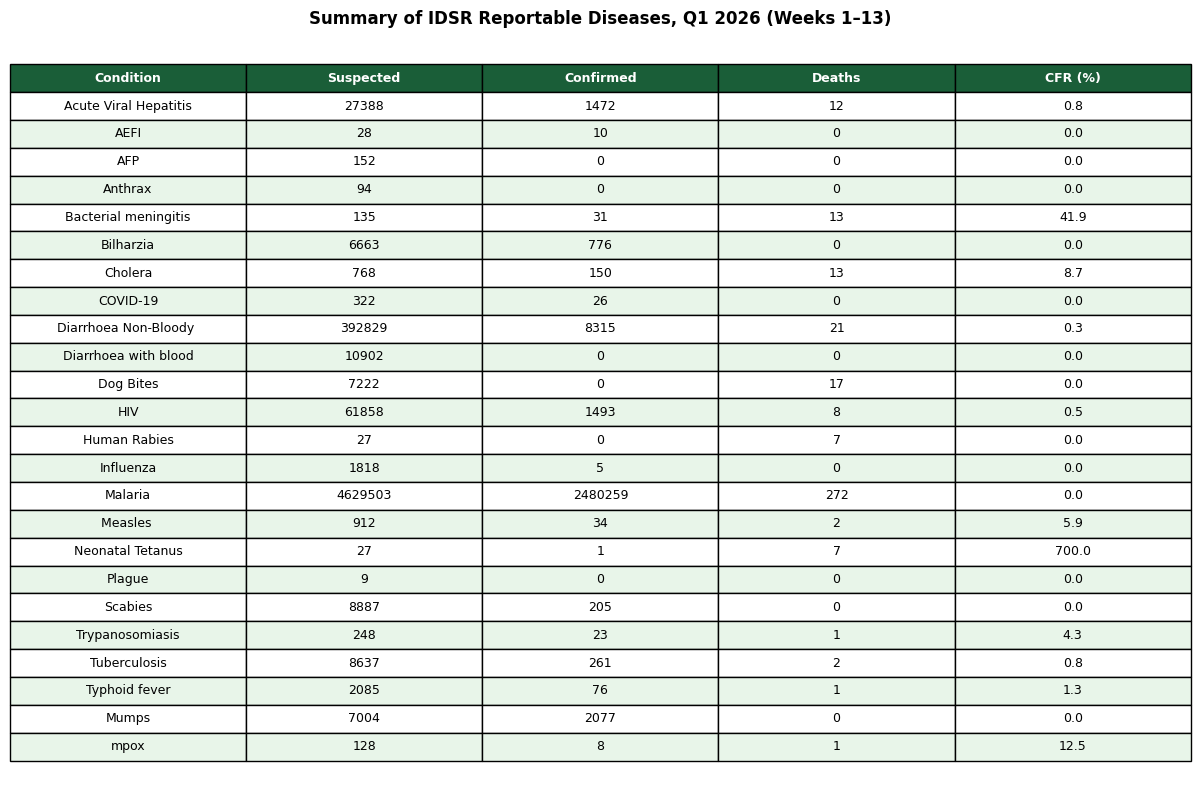

Saved: Summary_Table.png


In [22]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

display_cols = ['Condition', 'Suspected', 'Confirmed', 'Deaths', 'CFR (%)']
table_data   = summary[display_cols].fillna(0)
table_data[['Suspected','Confirmed','Deaths']] = table_data[['Suspected','Confirmed','Deaths']].astype(int)

tbl = ax.table(
    cellText=table_data.values,
    colLabels=display_cols,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.4)

# Header row — dark green
for j in range(len(display_cols)):
    tbl[0, j].set_facecolor('#1a5e38')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Alternating row shading — light greens
for i in range(1, len(table_data) + 1):
    color = '#e8f5e9' if i % 2 == 0 else '#ffffff'
    for j in range(len(display_cols)):
        tbl[i, j].set_facecolor(color)

ax.set_title(
    'Summary of IDSR Reportable Diseases, Q1 2026 (Weeks 1–13)',
    **TITLE_FONT, pad=15
)

plt.tight_layout()
plt.savefig('Summary_Table.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: Summary_Table.png')

## 5. IDSR Completeness and Timeliness

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


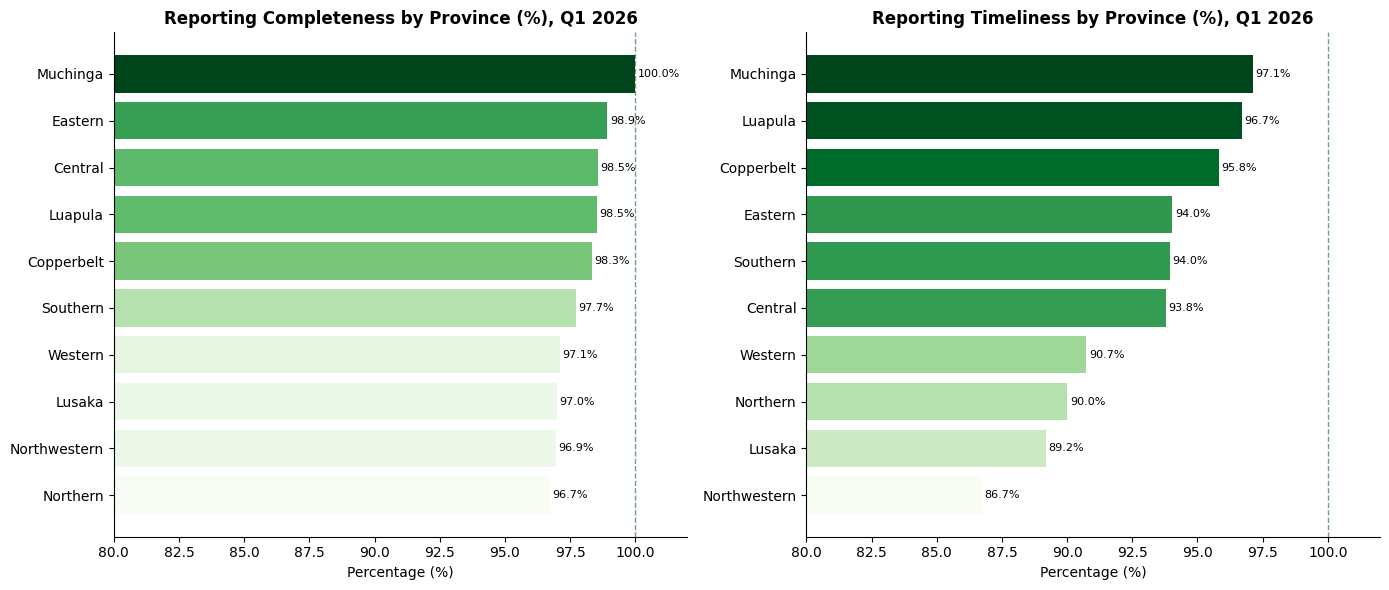

Saved: IDSR_Completeness_Timeliness.png


In [23]:
idsr_sorted = idsr.sort_values('Completeness %', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = [
    ('Completeness %', 'Reporting Completeness by Province (%), Q1 2026', axes[0]),
    ('Timeliness %',   'Reporting Timeliness by Province (%), Q1 2026',   axes[1]),
]

for col, title, ax in metrics:
    sorted_df = idsr.sort_values(col, ascending=True)
    bars = ax.barh(
        sorted_df['Province'],
        sorted_df[col],
        color=plt.cm.Greens(
            [(v - sorted_df[col].min()) / (sorted_df[col].max() - sorted_df[col].min() + 0.01)
             for v in sorted_df[col]]
        )
    )
    ax.set_xlim(80, 102)
    ax.set_xlabel('Percentage (%)', fontsize=10)
    ax.set_title(title, **TITLE_FONT)
    ax.axvline(x=100, color='#1a5e38', linestyle='--', linewidth=1, alpha=0.6)
    # Value labels
    for bar, val in zip(bars, sorted_df[col]):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('IDSR_Completeness_Timeliness.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: IDSR_Completeness_Timeliness.png')

## 6. Choropleth Maps by Disease

In [24]:
# Load shapefile
zambia = gpd.read_file('../gadm41_ZMB_1.json')

# Prep cases distribution
cases_dist.columns = cases_dist.columns.str.strip()
cases_dist['province'] = cases_dist['province'].replace({'Northwestern': 'North-Western'})
cases_dist = cases_dist.fillna(0)

# Merge with shapefile and reproject
zambia_map      = zambia.merge(cases_dist, left_on='NAME_1', right_on='province', how='left')
zambia_map_proj = zambia_map.to_crs(epsg=32735)

print('Shapefile merged. Available disease columns:')
disease_cols = [c for c in cases_dist.columns if c != 'province']
print(disease_cols)

Shapefile merged. Available disease columns:
['mpox', 'measles', 'afp', 'cholera', 'anthrax', 'diarrhoea non-bloody', 'influenza', 'aefi']


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


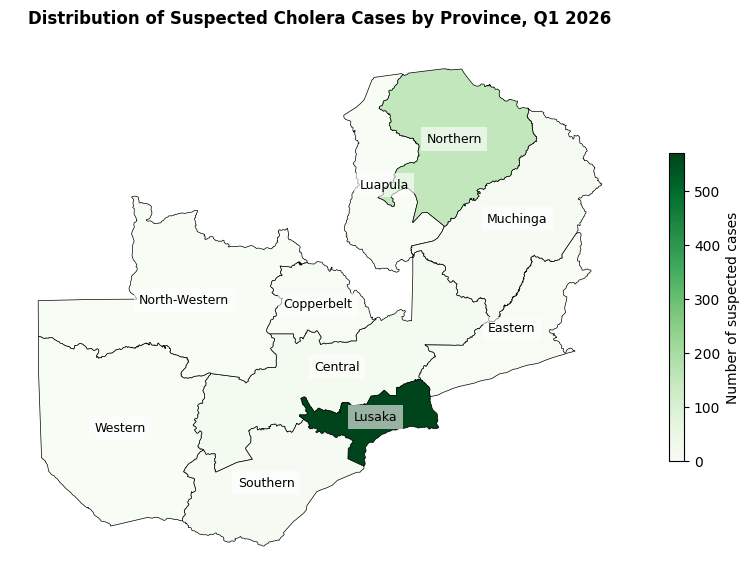

Saved: cholera.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


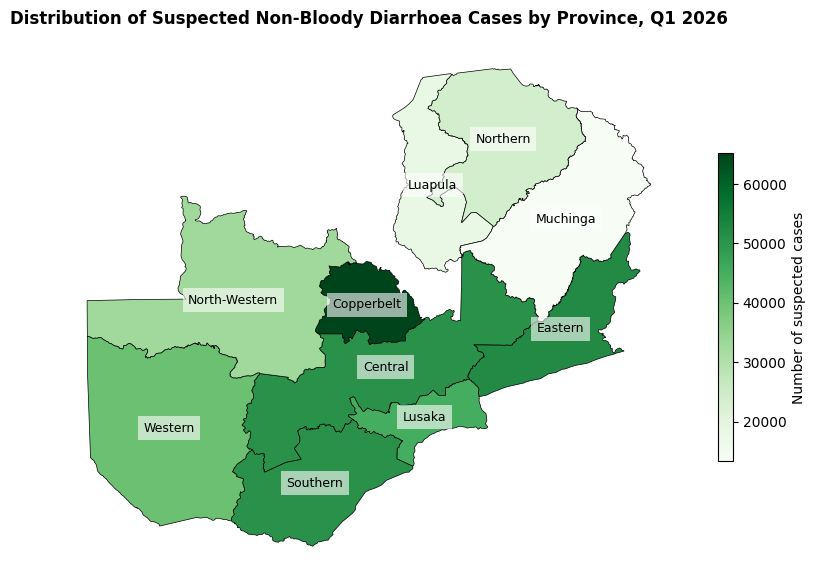

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: diarrhoea_non-bloody.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


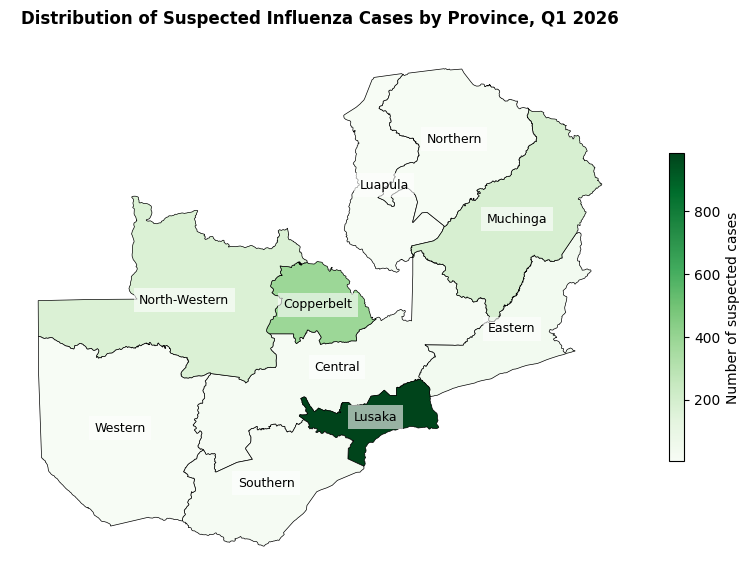

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: influenza.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


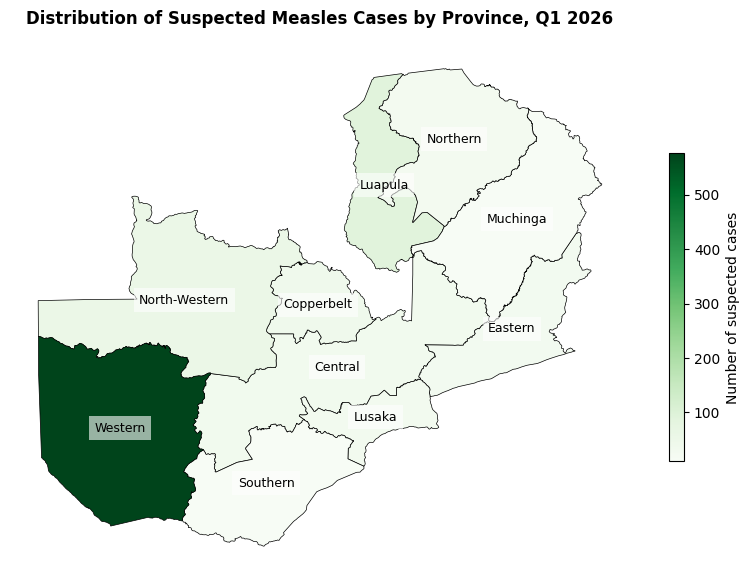

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: measles.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


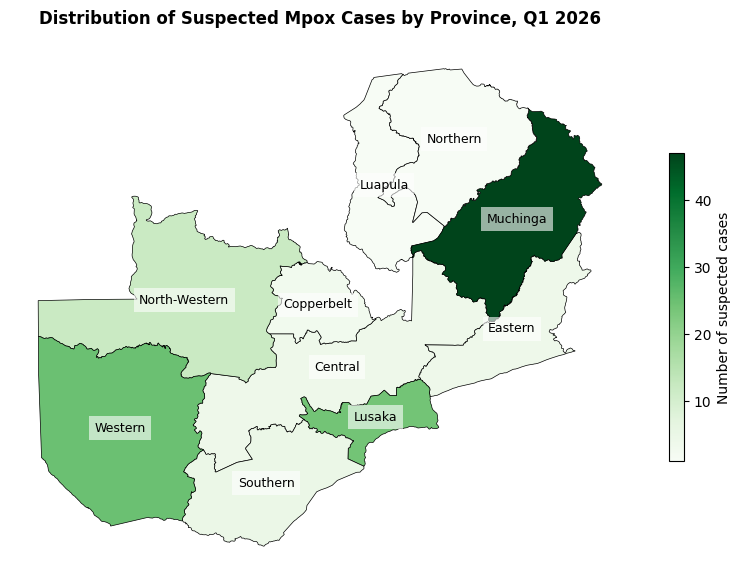

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: mpox.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


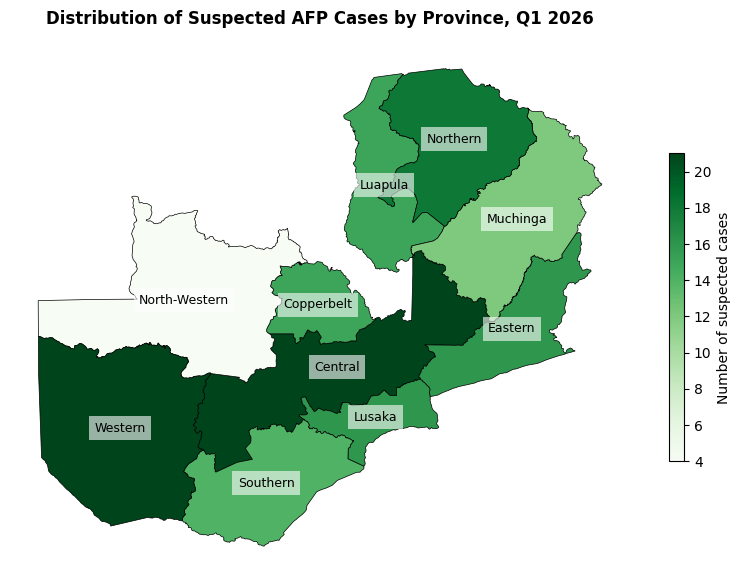

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: afp.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


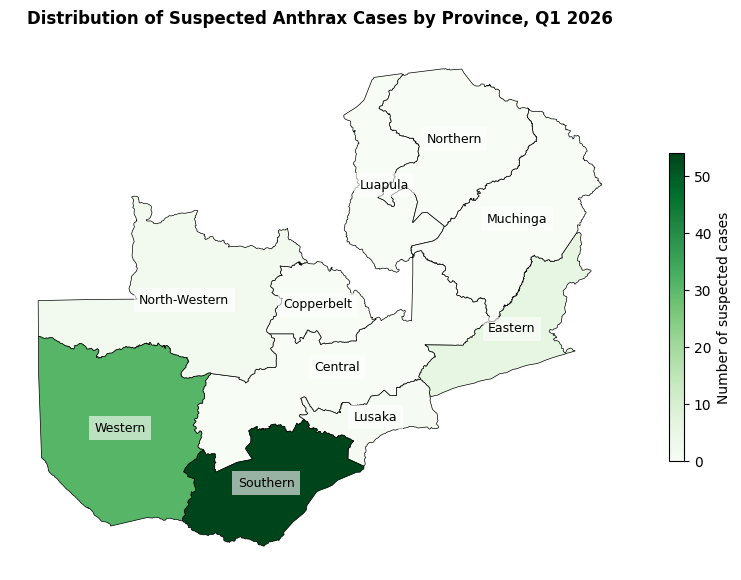

Saved: anthrax.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


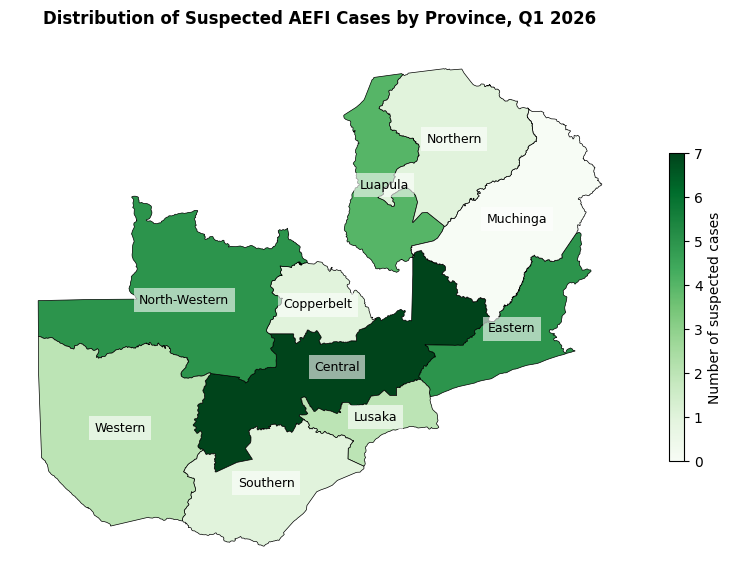

Saved: aefi.png


In [25]:
# Disease column → display title mapping
# Keys must exactly match column names in case_distribution.csv
diseases = {
    'cholera'             : 'Distribution of Suspected Cholera Cases by Province, Q1 2026',
    'diarrhoea non-bloody': 'Distribution of Suspected Non-Bloody Diarrhoea Cases by Province, Q1 2026',
    'influenza'           : 'Distribution of Suspected Influenza Cases by Province, Q1 2026',
    'measles'             : 'Distribution of Suspected Measles Cases by Province, Q1 2026',
    'mpox'                : 'Distribution of Suspected Mpox Cases by Province, Q1 2026',
    'afp'                 : 'Distribution of Suspected AFP Cases by Province, Q1 2026',
    'anthrax'             : 'Distribution of Suspected Anthrax Cases by Province, Q1 2026',
    'aefi'                : 'Distribution of Suspected AEFI Cases by Province, Q1 2026',
}

for disease_col, title in diseases.items():

    if disease_col not in zambia_map_proj.columns:
        print(f'WARNING: "{disease_col}" not found in cases data — skipping.')
        continue

    # Warn about unmatched provinces
    unmatched = zambia_map_proj[zambia_map_proj[disease_col].isna()]['NAME_1'].tolist()
    if unmatched:
        print(f'WARNING: No data for {unmatched} in "{disease_col}" — will appear blank.')

    fig, ax = plt.subplots(figsize=(10, 10))

    zambia_map_proj.plot(
        column=disease_col,
        cmap=CMAP,
        legend=True,
        legend_kwds={'shrink': 0.4, 'label': 'Number of suspected cases'},
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )

    ax.axis('off')
    ax.set_title(title, **TITLE_FONT, pad=15)

    # Province labels
    for x, y, label in zip(
        zambia_map_proj.geometry.centroid.x,
        zambia_map_proj.geometry.centroid.y,
        zambia_map_proj['NAME_1']
    ):
        ax.text(x, y, label, fontsize=9, ha='center', va='center', color='black',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    filename = disease_col.replace(' ', '_').replace('/', '-') + '.png'
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

## 7. Weekly Epi Curves (Q1 — Weeks 1–13)

In [26]:
# Strip whitespace from Condition column
weekly.columns = weekly.columns.str.strip()
weekly['Condition'] = weekly['Condition'].str.strip()

# Identify week columns and restrict to Q1 (Weeks 1–13)
all_week_cols = [col for col in weekly.columns if 'Week' in col]
q1_week_cols  = all_week_cols[:Q1_WEEKS]

# Parse week start dates from column names
# Format: "Week X YYYY-MM-DD - YYYY-MM-DD"
week_dates = [pd.to_datetime(col.split(' ')[2], format='%Y-%m-%d') for col in q1_week_cols]
week_labels = [f'W{i+1}' for i in range(Q1_WEEKS)]

print(f'Q1 weeks: {q1_week_cols[0]}  →  {q1_week_cols[-1]}')
print(f'Diseases available: {weekly["Condition"].tolist()}')

Q1 weeks: Week 1 2025-12-29 - 2026-01-04  →  Week 13 2026-03-23 - 2026-03-29
Diseases available: ['AFP', 'AEFI', 'Acute Viral Hepatitis', 'Anthrax', 'Cholera', 'COVID-19', 'Dog Bites', 'Influenza', 'Measles', 'Diarrhoea Non-Bloody', 'Bilharzia', 'Trypanosomiasis', 'Tuberculosis', 'Typhoid fever', 'Diarrhoea with blood', 'mpox']


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


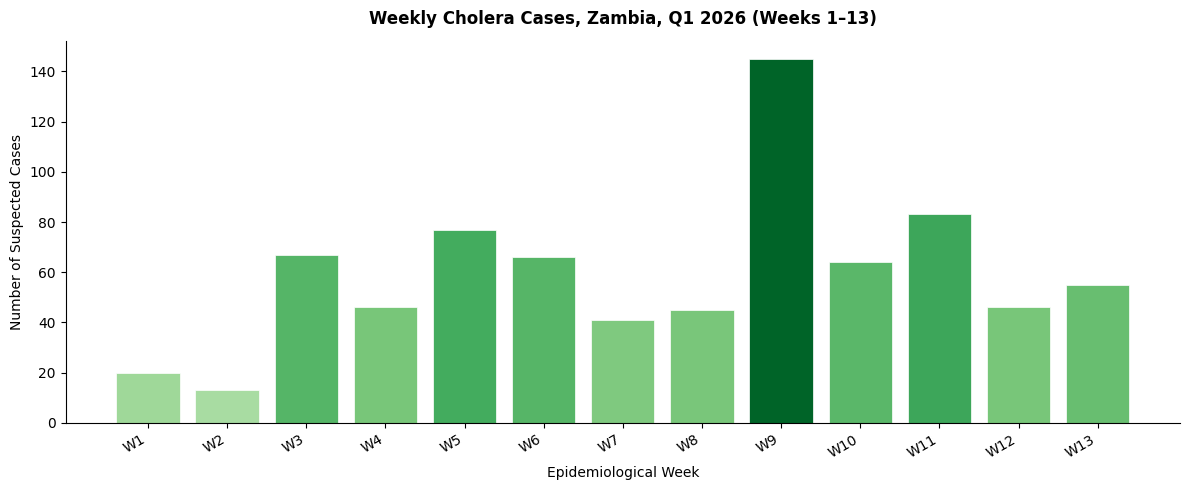

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: EpiCurve_Cholera.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


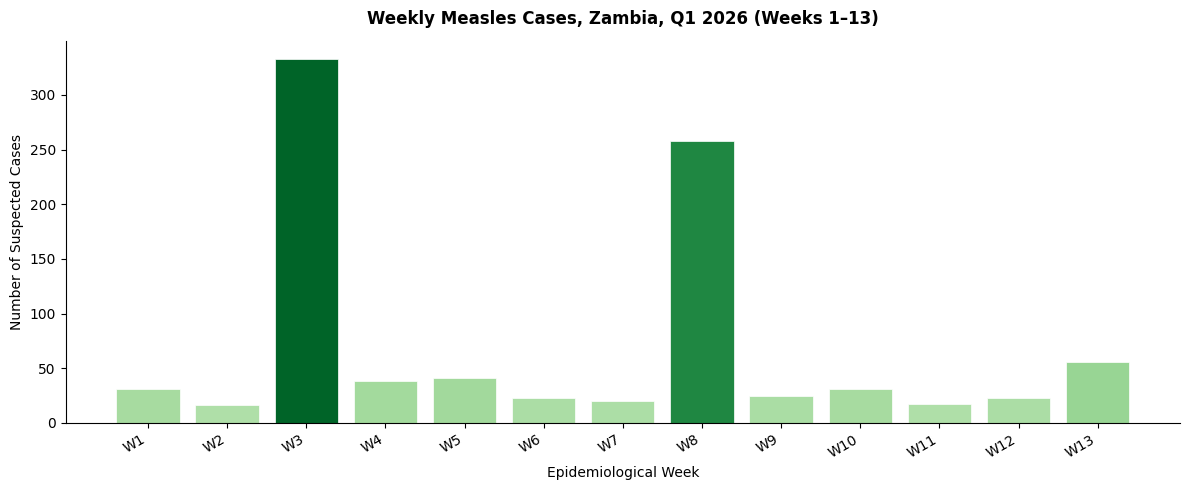

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: EpiCurve_Measles.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


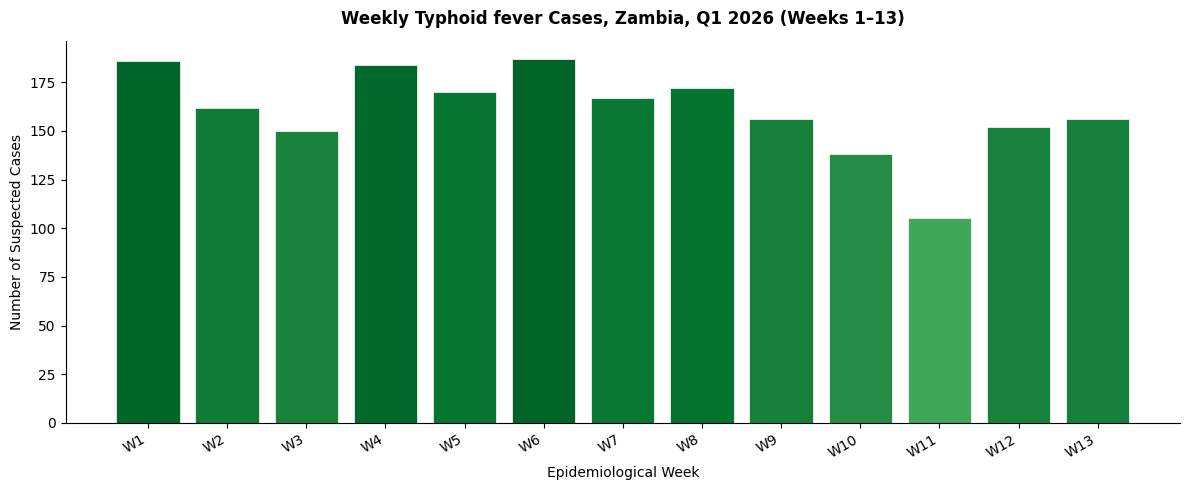

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: EpiCurve_Typhoid_fever.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


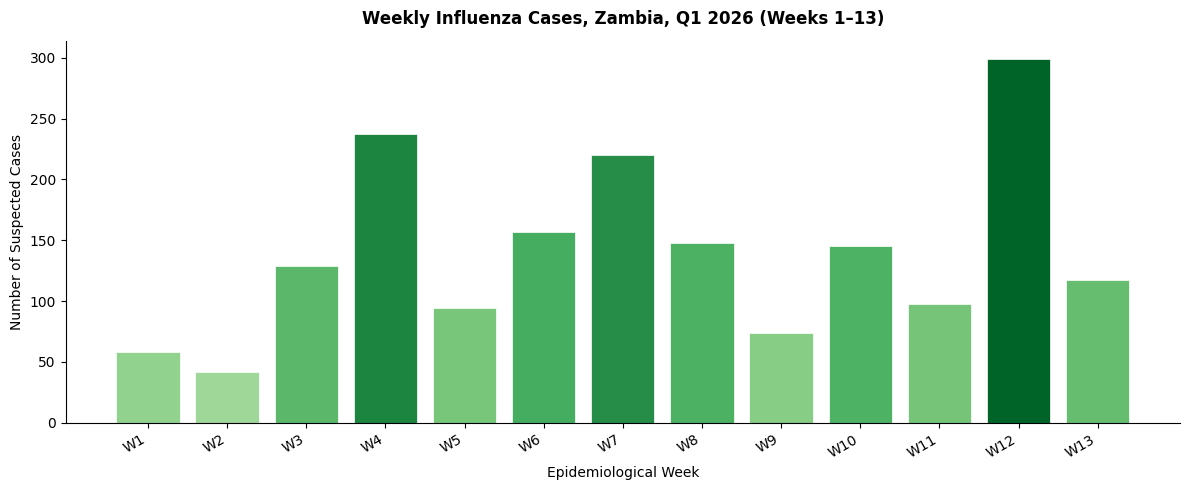

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: EpiCurve_Influenza.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


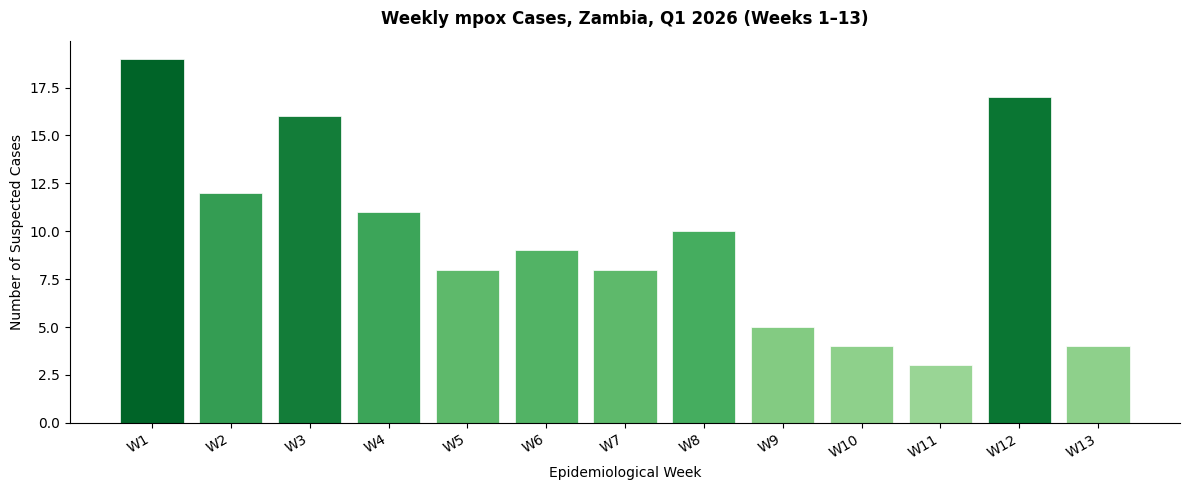

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: EpiCurve_mpox.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


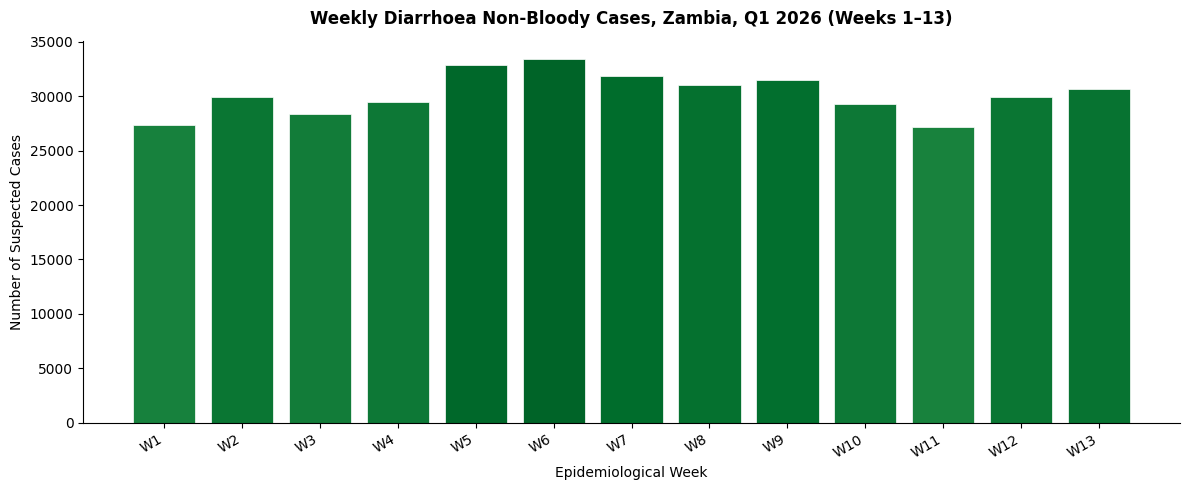

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Saved: EpiCurve_Diarrhoea_Non-Bloody.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


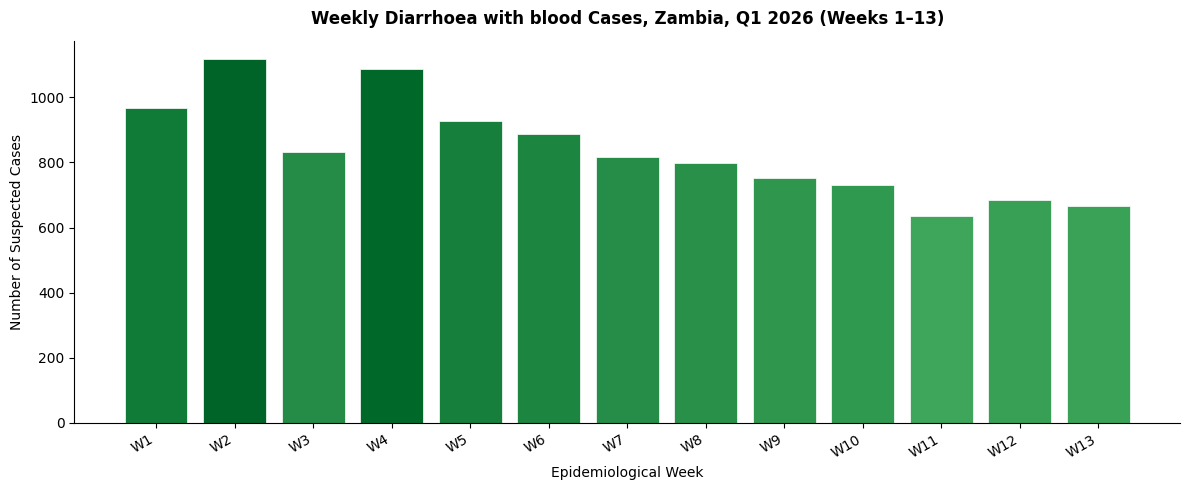

Saved: EpiCurve_Diarrhoea_with_blood.png


In [27]:
# Diseases to plot individual epi curves for
epi_diseases = [
    'Cholera',
    'Measles',
    'Typhoid fever',
    'Influenza',
    'mpox',
    'Diarrhoea Non-Bloody',
    'Diarrhoea with blood',
]

for disease in epi_diseases:
    row = weekly[weekly['Condition'] == disease]

    if row.empty:
        print(f'WARNING: "{disease}" not found in weekly data — skipping.')
        continue

    cases = row[q1_week_cols].iloc[0].astype(float).fillna(0)

    # Colour bars by intensity using Greens colormap
    norm_vals = cases / cases.max() if cases.max() > 0 else cases
    colours   = plt.cm.Greens(0.3 + 0.6 * norm_vals)  # range 0.3–0.9 for visible contrast

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(week_labels, cases, color=colours, edgecolor='white', linewidth=0.5)

    ax.set_title(
        f'Weekly {disease} Cases, Zambia, Q1 2026 (Weeks 1–13)',
        **TITLE_FONT, pad=12
    )
    ax.set_xlabel('Epidemiological Week', fontsize=10)
    ax.set_ylabel('Number of Suspected Cases', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()

    filename = f'EpiCurve_{disease.replace(" ", "_")}.png'
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

## 8. Multi-Disease Epi Curve Overview

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

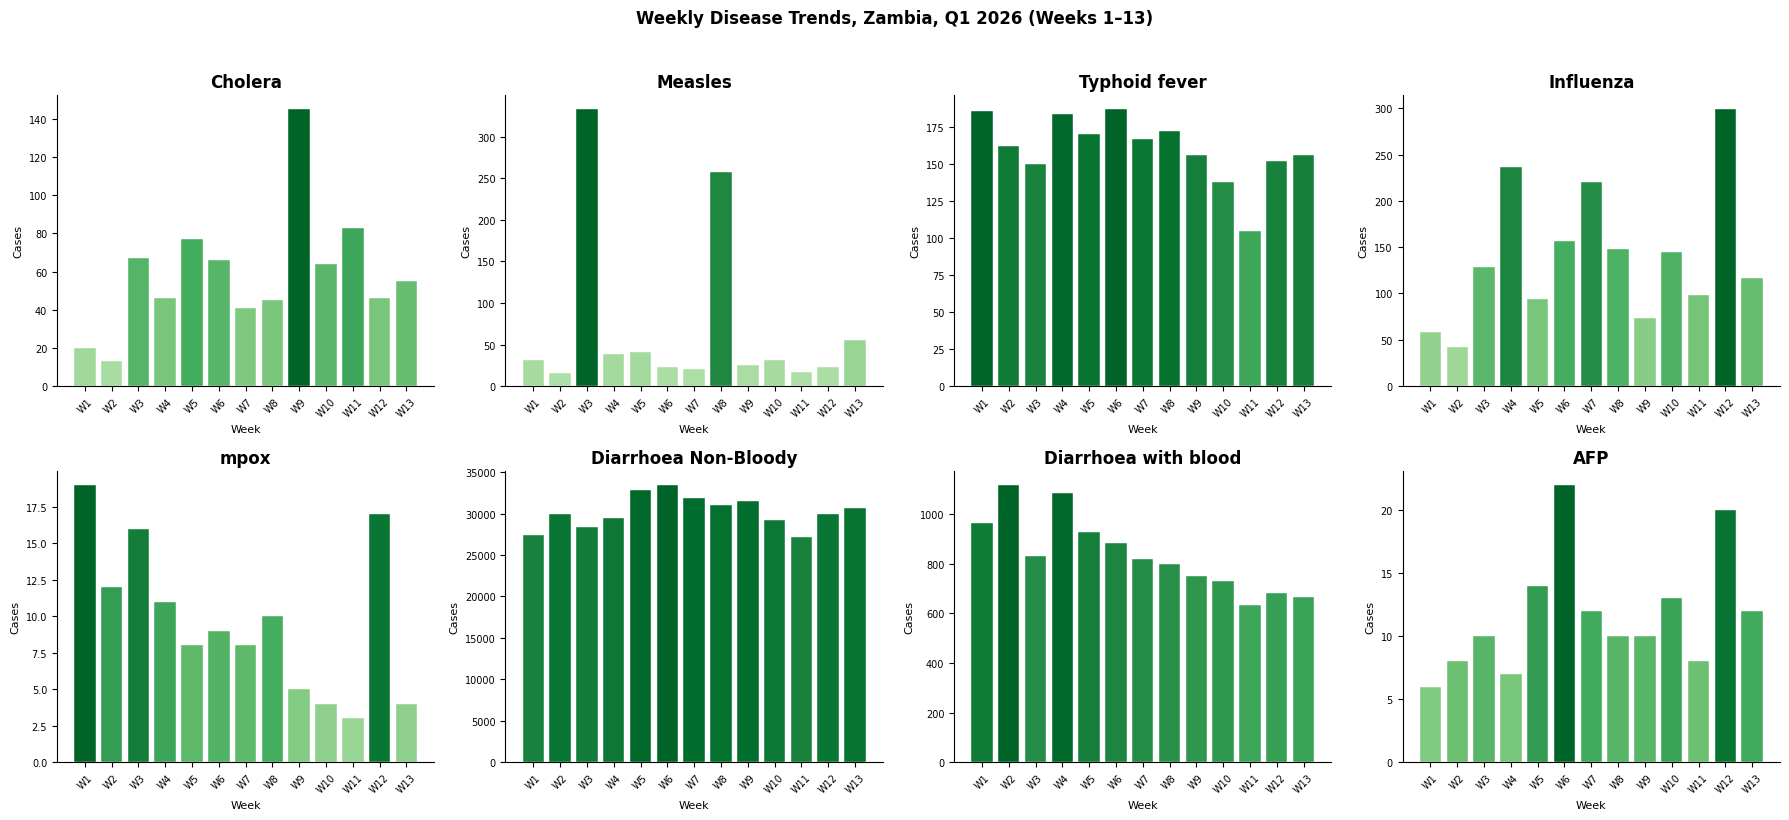

Saved: EpiCurve_Overview.png


In [28]:
# Small multiples — all key diseases in one figure
overview_diseases = ['Cholera', 'Measles', 'Typhoid fever', 'Influenza',
                     'mpox', 'Diarrhoea Non-Bloody', 'Diarrhoea with blood', 'AFP']

available = [d for d in overview_diseases if not weekly[weekly['Condition'] == d].empty]
n = len(available)
ncols = 4
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, disease in enumerate(available):
    ax = axes[i]
    row = weekly[weekly['Condition'] == disease]
    cases = row[q1_week_cols].iloc[0].astype(float).fillna(0)
    norm_vals = cases / cases.max() if cases.max() > 0 else cases
    colours   = plt.cm.Greens(0.3 + 0.6 * norm_vals)

    ax.bar(week_labels, cases, color=colours, edgecolor='white', linewidth=0.3)
    ax.set_title(disease, **TITLE_FONT)
    ax.set_xlabel('Week', fontsize=8)
    ax.set_ylabel('Cases', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Weekly Disease Trends, Zambia, Q1 2026 (Weeks 1–13)',
    **TITLE_FONT, y=1.02
)
plt.tight_layout()
plt.savefig('EpiCurve_Overview.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: EpiCurve_Overview.png')